#### Exercise 7 - Starter - Event Study Model 

For the author's solution, please refer to his github [here](https://github.com/udacity/causal-inference-foundations/blob/main/Exercise7-event-study/solution/sbux-ceo-change.ipynb). My solution below is similar but not exact.

## Context

In Aug 2024, Starbucks announced a CEO change without any other materially confounding information (e.g. it wasn't along an earnings report). Events like these are something companies and investors are regularly interested in quantifying impact -- but naturally don't want to design an experiment randomly giving users bad experiences

Examples of how this might transfer: Suppose there is an outage that affects a certain region or population of users (iOs but not Android, NYC but not San Francisco or LA, purchasers of product X but not Y, etc.). If you have a time series of performance by these groups, you may consider these models to estimate the impact.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import statsmodels.formula.api as smf

In [2]:
event_date = '2024-08-13'
# prices = pd.read_csv('../data/sbux_ceo_prices.csv')
prices=pd.read_csv('https://raw.githubusercontent.com/udacity/causal-inference-foundations/refs/heads/main/Exercise7-event-study/data/sbux_ceo_prices.csv')
prices = prices[prices['returns'].isnull()==0].copy()
print(prices['date'].agg(['min','max']))
prices.head()

min    2024-01-03
max    2024-08-30
Name: date, dtype: object


,date,open,high,low,close,adjclose,volume,ticker,returns
1,2024-01-03,93.959999,94.239998,93.059998,93.230003,89.737869,7161700,SBUX,-0.004697
2,2024-01-04,93.099998,94.580002,93.000000,93.550003,90.045891,7118600,SBUX,0.003432
3,2024-01-05,93.330002,93.580002,92.480003,92.989998,89.506851,7189900,SBUX,-0.005986
4,2024-01-08,93.019997,94.570000,92.949997,94.190002,90.661919,7536900,SBUX,0.012905
5,2024-01-09,93.610001,93.730003,92.860001,93.089996,89.603111,6348500,SBUX,-0.011679


### Estimate event study model

In [3]:
#TO-DO: EVENT STUDIES REQUIRE EACH COMPARISON GROUP TO BE A SEPARATE COLUMN. 
# RESHAPE THE DATA SO THAT THERE IS ONE ROW PER DATE AND EACH TICKER HAS ITS OWN COLUMN 
prices['date']=pd.to_datetime(prices['date'])
price_wide=pd.pivot_table(data=prices, index='date', columns='ticker', values='returns').reset_index()
price_wide.head()

ticker,date,MCD,SBUX,VOO,YUM
0,2024-01-03,-0.008921,-0.004697,-0.007419,0.000543
1,2024-01-04,-0.009002,0.003432,-0.003157,-0.003176
2,2024-01-05,-0.009426,-0.005986,0.001281,-0.002720
3,2024-01-08,0.010070,0.012905,0.014303,0.002338
4,2024-01-09,-0.003529,-0.011679,-0.002430,-0.003265


In [4]:
preperiod_days = 120
postperiod_days = 1

event_date = pd.to_datetime(event_date)
model_start_date = event_date-pd.DateOffset(days=preperiod_days)
model_end_date = event_date+pd.DateOffset(days=postperiod_days)

# TO-DO: SUBSET THE DATA FOR RELEVANT DATES AND THEN RUN THE EVENT STUDY MODEL 
subset = price_wide[(price_wide['date'] >= model_start_date)&(price_wide['date']< model_end_date)].copy()
subset['event']=(subset['date']==event_date).astype(int)
formula = 'SBUX~MCD+VOO+YUM+event'
model = smf.ols(formula=formula, data=subset).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   SBUX   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     36.91
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           2.23e-17
Time:                        11:59:11   Log-Likelihood:                 203.84
No. Observations:                  84   AIC:                            -397.7
Df Residuals:                      79   BIC:                            -385.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0007      0.002     -0.295      0.7

- The coef of `event` param is 0.229, meaning about 23% increase of Starbuck returns in comparison to its competitors.

In [5]:
# TO-DO: 1. Obtain the baseline market value (shares * price) just prior to the event date; price is the 'close' column 
#        2. What is the estimated nominal market value gain (in dollars) from the event? 

total_shares = 1132800000

pre_last_day = prices[prices['date']<event_date]['date'].max()
last_price = prices[(prices['date']==pre_last_day) & (prices['ticker']=='SBUX')]['close'].values[0]
lastmarketvalue=last_price*total_shares

print("Last Market Value: ${:,}".format(round(lastmarketvalue)))
print("Estimated Gain: ${:,}".format(model.params['event']*lastmarketvalue))

Last Market Value: $87,259,582,617
Estimated Gain: $19,976,389,929.08283


In [6]:
# TO-DO: Get a distribution of placebo results
# 1. Replicate the analysis for each day for 120 days prior to the true event date: 
#    For each date between (event_date - 120 and event_date - 1), pretend that is the event. 
# 2. Save the distribution of placebo treatment effect estimates for each of those dates
# 3. Plot the distribution as a histogram with black vertical lines for the 95% confidence interval bounds 
#    and a red vertical line for the effect at the real event date
# 4. What is the root mean squared error of the placebo effects? 
#    You want a small RMSE (low variance) and the distribution should be centered around zero (unbiased)

pre_event_dates = prices[(prices['date']>=(event_date-pd.Timedelta(days=120))) & (prices['date']<event_date)]['date'].unique()

pvalues=[]
betas=[]

start_dates = []
end_dates = []
event_placebo_dates = []

formula = 'SBUX~MCD+VOO+YUM+event'

for placebo_event_date in pre_event_dates:
    model_start_date = placebo_event_date-pd.Timedelta(days=preperiod_days)
    model_end_date = placebo_event_date+pd.Timedelta(days=postperiod_days)
    
    subset = price_wide[(price_wide['date'] >= model_start_date) & (price_wide['date']<model_end_date)].copy()
    subset['event']=(subset['date']==placebo_event_date).astype(int)
    
    placebo_model=smf.ols(formula=formula, data=subset).fit()
    pvalues.append(placebo_model.pvalues['event'])
    betas.append(placebo_model.params['event'])
    start_dates.append(model_start_date)
    end_dates.append(model_end_date)
    event_placebo_dates.append(placebo_event_date)

placebo_df = pd.DataFrame(
{'start_date': start_dates,
 'end_date': end_dates,
 'event_date': event_placebo_dates,
 'beta_estimates': betas,
 'pvalues': pvalues
}
)

avg_betas = np.mean(betas)
rmse = np.sqrt(np.mean(np.array(betas)**2))

print(f"Mean Placebo Effect: {avg_betas:.3f}")
print(f"RMSE: {rmse:.3f}")

Mean Placebo Effect: 0.001
RMSE: 0.026


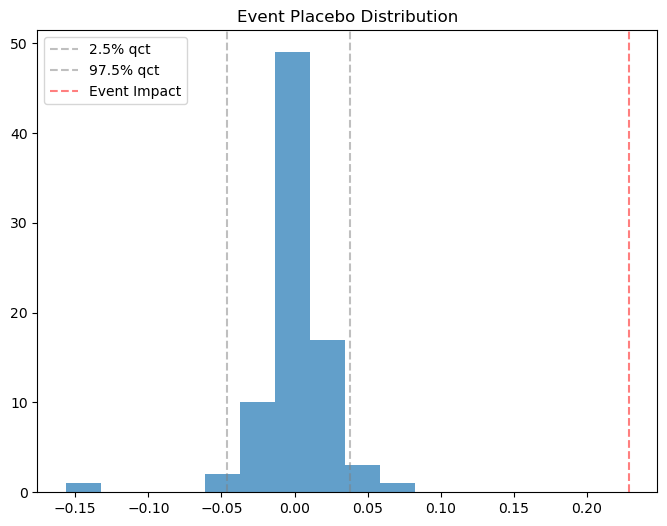

In [7]:
quantile_2_5=np.quantile(betas, 0.025)
quantile_97_5=np.quantile(betas, 0.975)
model_est = model.params['event']

plt.figure(figsize=(8, 6))
plt.hist(betas, bins=10, alpha=0.7)
plt.axvline(quantile_2_5, linestyle='--', color='gray', alpha=0.5, label='2.5% qct')
plt.axvline(quantile_97_5, linestyle='--', color='gray', alpha=0.5, label='97.5% qct')
plt.axvline(model_est, linestyle='--', color='red', alpha=0.5, label='Event Impact')
plt.legend(loc='upper left')
plt.title('Event Placebo Distribution')
plt.show()

## making functions
- event placebos
- plot historgram

In [8]:
def get_event_study_placebos(df_wide, pre_event_dates, duration_days, formula):

    pvalues=[]
    betas=[]
    
    start_dates = []
    end_dates = []
    event_placebo_dates = []
    
    for placebo_event_date in pre_event_dates:
        
        model_start_date = placebo_event_date-pd.Timedelta(days=duration_days)
        
        subset = df_wide[(df_wide['date'] >= model_start_date) & (df_wide['date']<=placebo_event_date)].copy()
        subset['event']=(subset['date']==placebo_event_date).astype(int)
        
        placebo_model=smf.ols(formula=formula, data=subset).fit()
        pvalues.append(placebo_model.pvalues['event'])
        betas.append(placebo_model.params['event'])
        start_dates.append(model_start_date)
        event_placebo_dates.append(placebo_event_date)
    
    placebo_df = pd.DataFrame(
    {'start_date': start_dates,
     'event_date': event_placebo_dates,
     'beta_estimates': betas,
     'pvalues': pvalues
    }
    )

    return placebo_df

In [9]:
new_placebo = get_event_study_placebos(price_wide, pre_event_dates, 120, formula)
new_placebo.head()

,start_date,event_date,beta_estimates,pvalues
0,2023-12-17,2024-04-15,0.012780,0.197753
1,2023-12-18,2024-04-16,0.005805,0.547948
2,2023-12-19,2024-04-17,0.011769,0.247165
3,2023-12-20,2024-04-18,0.012599,0.194500
4,2023-12-21,2024-04-19,0.009550,0.333268


In [10]:
placebo_rmse=np.sqrt((new_placebo['beta_estimates']**2).mean())
print(f'rmse: {placebo_rmse:.3f}')

rmse: 0.026


In [11]:
def plot_histogram(placebo_values, actual_values, title):
    quantile_2_5=np.quantile(placebo_values, 0.025)
    quantile_97_5=np.quantile(placebo_values, 0.975)
    
    plt.figure(figsize=(8, 6))
    plt.hist(placebo_values, bins=10, alpha=0.7)
    plt.axvline(quantile_2_5, linestyle='--', color='gray', alpha=0.5, label='2.5% qct')
    plt.axvline(quantile_97_5, linestyle='--', color='gray', alpha=0.5, label='97.5% qct')
    plt.axvline(actual_values, linestyle='--', color='red', alpha=0.5, label='Event Impact')
    plt.legend(loc='upper left')
    plt.title(title)
    plt.show()

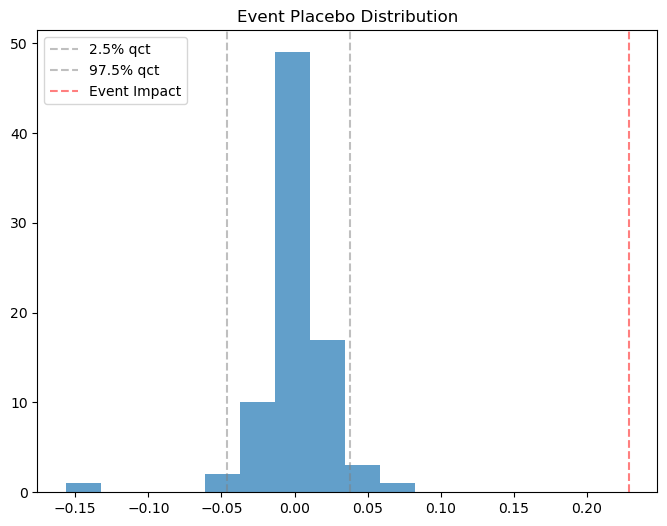

In [12]:
plot_histogram(betas, model.params['event'], 'Event Placebo Distribution')

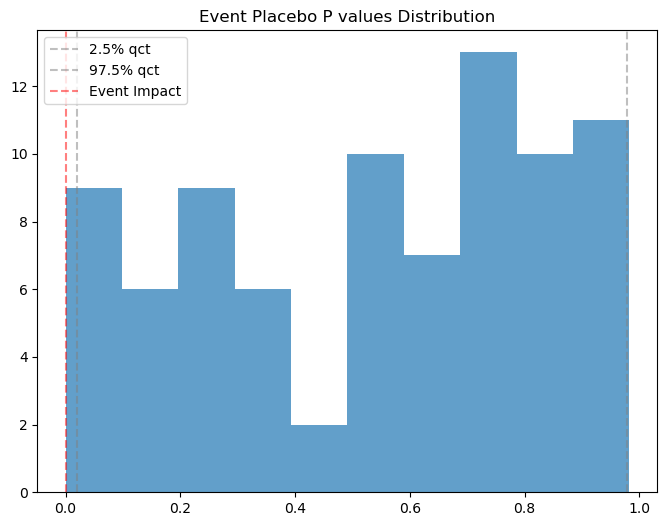

In [13]:
plot_histogram(pvalues, model.pvalues['event'], 'Event Placebo P values Distribution')

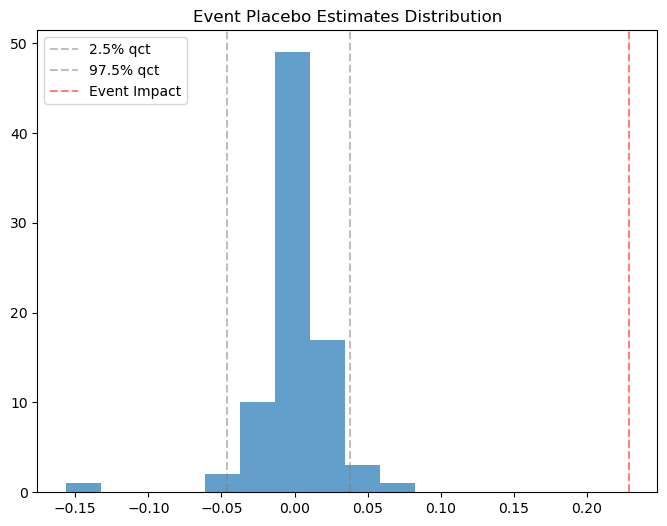

In [14]:
plot_histogram(new_placebo['beta_estimates'], model.params['event'], 'Event Placebo Estimates Distribution')